<font size = '18'> What is the most optimal skill to learn for Data Analysts? </font>

<h1> Methodology</h1>
<p style = "font-size : 12 pt;">1. Group skills to determine median salary and likelihood of being in posting. </p>
<p style = "font-size : 12 pt;">2. Visualize median salry vs percent skill demand. </p>
<p style = "font-size : 12 pt;">3. (Optional) Determine if certain technologies are more prevalent.</p>

In [14]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills']=  df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /Users/sachintamangyonjan/.cache/huggingface/datasets/lukebarousse___data_jobs/default/0.0.0/1d815e9ce232eb27db11939c44eb048fe6d2e9ab (last modified on Sun Sep 29 14:34:04 2024).


In [15]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

In [16]:
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_US_exploded = df_DA_US.explode('job_skills')

df_DA_US_exploded[['salary_year_avg','job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [17]:
df_DA_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by = 'count', ascending = False)

df_DA_skills = df_DA_skills.rename(columns = {'count': 'skill_count', 'median': 'median_salary'})

df_DA_skills

,skill_count,median_salary
job_skills,,
sql,2508,91000.0
excel,1808,84392.0
python,1431,97500.0
tableau,1364,92875.0
sas,926,90000.0
...,...,...
couchbase,1,160515.0
chainer,1,100000.0
chef,1,85000.0


In [18]:
dA_job_count = len(df_DA_US)

In [19]:
df_DA_skills['skill_percent'] = df_DA_skills['skill_count']/  dA_job_count* 100
df_DA_skills

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.0,57.655172
excel,1808,84392.0,41.563218
python,1431,97500.0,32.896552
tableau,1364,92875.0,31.356322
sas,926,90000.0,21.287356
...,...,...,...
couchbase,1,160515.0,0.022989
chainer,1,100000.0,0.022989
chef,1,85000.0,0.022989


In [26]:
skill_percent = 5
df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]
df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


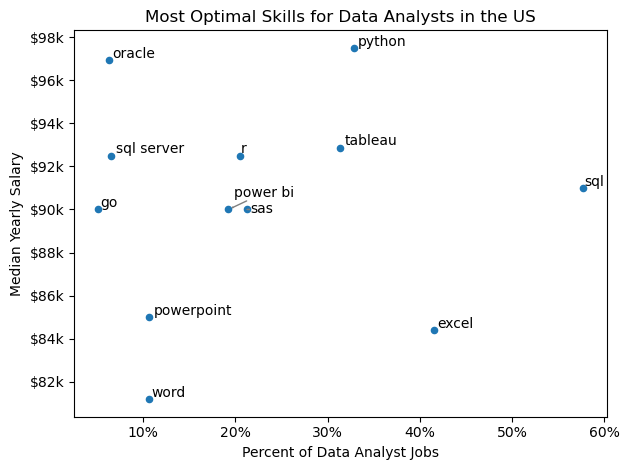

In [37]:
from adjustText import adjust_text
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import PercentFormatter
df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals = 0))

# Adjust layout and display plot 
plt.tight_layout()
plt.show()

In [44]:
type(df['job_type_skills'])

pandas.core.series.Series

In [85]:
df_technology = df['job_type_skills'].copy()

# Remove Duplicates
df_technology = df_technology.drop_duplicates()

# Remove NaN values
df_technology = df_technology.dropna()

# Combine all the dictionaries into one
technology_dict = {}

for row in df_technology:
    row_dict = ast.literal_eval(row)  # Convert string into dictionary
    
    for key, value in row_dict.items():
        if key in technology_dict:    # If key already exists in technolody_dict
            technology_dict[key] += value 
        else:
            technology_dict[key] = value

# Remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))
    
technology_dict

{'analyst_tools': ['powerpoint',
  'outlook',
  'spreadsheet',
  'sheets',
  'word',
  'tableau',
  'ssrs',
  'esquisse',
  'powerbi',
  'spss',
  'ssis',
  'excel',
  'looker',
  'ms access',
  'sas',
  'sap',
  'msaccess',
  'cognos',
  'visio',
  'nuix',
  'dax',
  'alteryx',
  'datarobot',
  'sharepoint',
  'power bi',
  'splunk',
  'qlik',
  'microstrategy'],
 'programming': ['perl',
  'mongodb',
  'html',
  'kotlin',
  'assembly',
  'cobol',
  'clojure',
  'no-sql',
  'r',
  'bash',
  'vb.net',
  'golang',
  'f#',
  'shell',
  'elixir',
  'fortran',
  'nosql',
  'matlab',
  'sass',
  'sql',
  'powershell',
  'erlang',
  'rust',
  'css',
  'c#',
  'lua',
  'ocaml',
  'objective-c',
  'scala',
  'solidity',
  'crystal',
  'php',
  'visualbasic',
  'visual basic',
  'c++',
  'vba',
  'delphi',
  't-sql',
  'python',
  'apl',
  'groovy',
  'go',
  'mongo',
  'lisp',
  'typescript',
  'sas',
  'ruby',
  'pascal',
  'haskell',
  'swift',
  'c',
  'julia',
  'dart',
  'javascript',
  'j

In [90]:
df_technology = pd.DataFrame(list(technology_dict.items()),columns = ['technology', 'skills'])

In [91]:
df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,powerpoint
0,analyst_tools,outlook
0,analyst_tools,spreadsheet
0,analyst_tools,sheets
0,analyst_tools,word
...,...,...
9,sync,ringcentral
9,sync,zoom
9,sync,slack
9,sync,unify


In [93]:
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on= 'job_skills', right_on= 'skills')

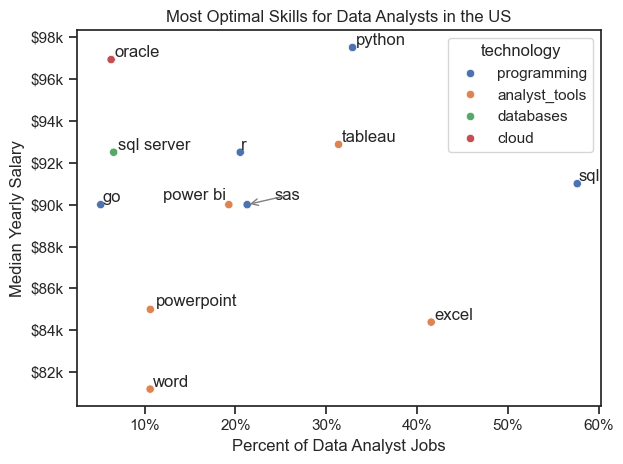

In [104]:
from adjustText import adjust_text
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import PercentFormatter

# df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')
sns.scatterplot(
    data =df_plot,
    x = 'skill_percent',
    y = 'median_salary',
    hue = 'technology' 
    )

# sns.despine()
# sns.set_theme(style='ticks')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, 
            expand_text = (1.2,1.4),    # Increase text offset
            expand_points = (1.4,1.5),  # Increase point offset
            force_text = 1.2,           # Slightly stronger force on text movements
            force_points = 1.2,         # Regular force on points
            autoaligh = 'xy',           # Allow auto-alighnemtn in x and y directions
            arrowprops=dict(arrowstyle='->', 
            color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals = 0))

# Adjust layout and display plot 
plt.tight_layout()
plt.show()